In [1]:
%pip install shap


[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import joblib
import pandas as pd
import shap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from preprocessing import extract_target
from text_features import clean_series

In [9]:
pipeline = joblib.load("models_results/XGBoost/pipeline.joblib")
label_encoder = joblib.load("models_results/XGBoost/label_encoder.joblib")
test_df = pd.read_csv("test.csv")

X_test, y_test = extract_target(test_df, 'Company response to consumer')
y_test_encoded = label_encoder.transform(y_test)

In [10]:
importances = pipeline.named_steps['clf'].feature_importances_
feature_names = pipeline.named_steps['preprocessing'].get_feature_names_out()

In [11]:

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
feature_importance_df.head(30)

,Feature,Importance
10045,categorical__Sub-product_General-purpose credi...,0.029776
10035,categorical__Sub-product_Credit reporting,0.022494
2402,text__company called,0.016219
10042,categorical__Sub-product_Federal student loan ...,0.015659
10001,categorical__Product_Checking or savings account,0.015580
1862,text__borrowed,0.013670
5753,text__lower interest,0.010385
10186,numeric__year,0.009790
10176,categorical__Company_Other,0.007860
9794,text__willing,0.007750


In [13]:
sample_size = 300
X_test_sample = X_test.sample(sample_size, random_state=42)

X_test_transformed = pipeline.named_steps['preprocessing'].transform(X_test_sample)

explainer = shap.TreeExplainer(pipeline.named_steps['clf'])
shap_values = explainer.shap_values(X_test_transformed)

/opt/anaconda3/envs/ml/lib/python3.11/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


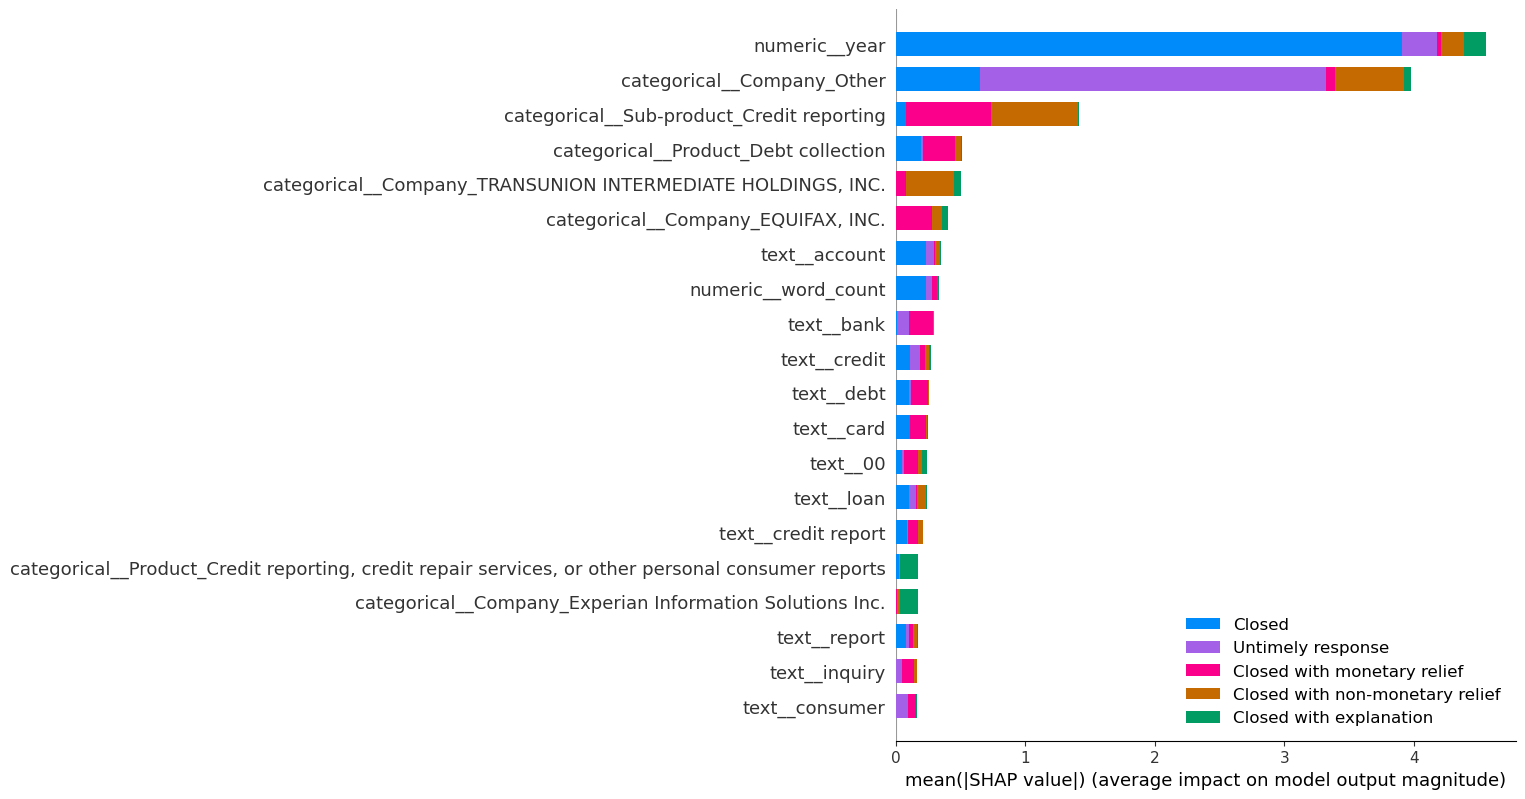

In [14]:
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, plot_type="bar",
                   class_names=label_encoder.classes_, max_display=20)

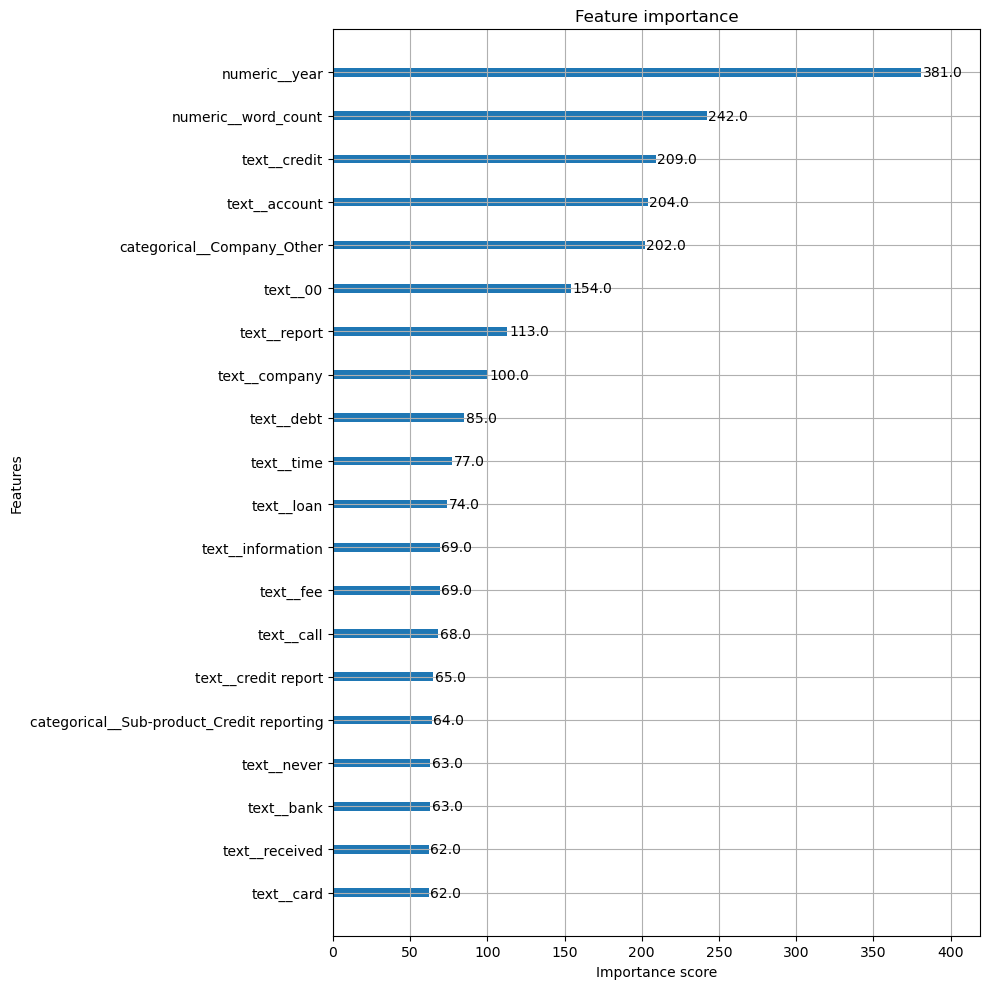

In [18]:
# feature importance with XGBoost
from xgboost import plot_importance

clf = pipeline.named_steps['clf']
feature_names = pipeline.named_steps['preprocessing'].get_feature_names_out()

clf.get_booster().feature_names = list(feature_names)

fig, ax = plt.subplots(figsize=(10, 10))
plot_importance(clf, max_num_features=20, ax=ax)
plt.tight_layout()
plt.show()

In [19]:
print(f"Total input features: {len(feature_names)}")

Total input features: 10187
